                                     Advanced Credit Card Fraud Detection System

Machine Learning Project

Objective:
The objective of this project is to build a machine learning model
to detect fraudulent credit card transactions using classification techniques.
The project also handles imbalanced data using SMOTE.

Name : Aliya Alim Shaikh


Algorithm Used : Logistic Regression , Decision Tree , KNN , Random Forest

IMPORT REQUIRED LIBRARIES

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from imblearn.over_sampling import SMOTE


LOAD DATASET


In [2]:
df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


BASIC DATA UNDERSTANDING (DATA PREPROCESSING)

In [4]:
df.shape

(284807, 31)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [7]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


CHECK CLASS DISTRIBUTION

In [8]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

VISUALIZE CLASS DISTRIBUTION

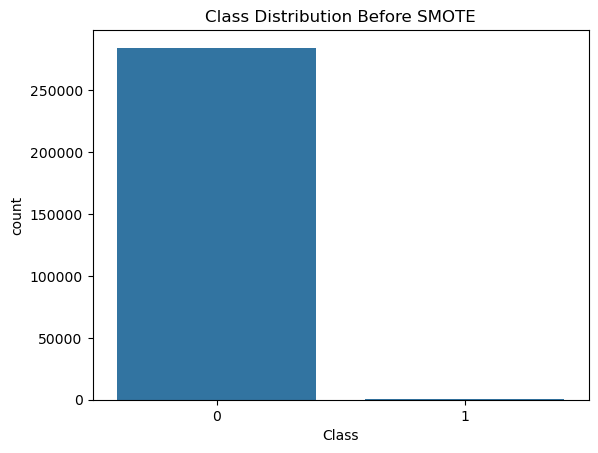

In [9]:
sns.countplot(x = 'Class',data = df)
plt.title("Class Distribution Before SMOTE")
plt.show()

FRAUD VS GENUINE PERCENTAGE

In [10]:
fraud = df['Class'].value_counts()[1]
normal = df['Class'].value_counts()[0]
print("Fraud Percentage: ",(fraud/len(df))*100)
print("Normal Percentage:",(normal/len(df))*100)

Fraud Percentage:  0.1727485630620034
Normal Percentage: 99.82725143693798


TRANSACTION AMOUNT ANALYSIS

In [11]:
fraud_df = df[df['Class'] == 1]
normal_df = df[df['Class'] == 0]

print("Fraud Transaction Amount Summary")
print(fraud_df['Amount'].describe())

print("Normal Transaction Amount Summary")
print(normal_df['Amount'].describe())

Fraud Transaction Amount Summary
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64
Normal Transaction Amount Summary
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


AMOUNT DISTRIBUTION GRAPH

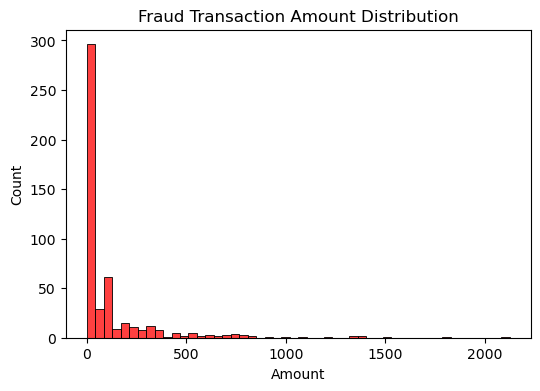

In [12]:
plt.figure(figsize = (6,4))
sns.histplot(fraud_df['Amount'],bins = 50,color = 'red')
plt.title("Fraud Transaction Amount Distribution")
plt.show()

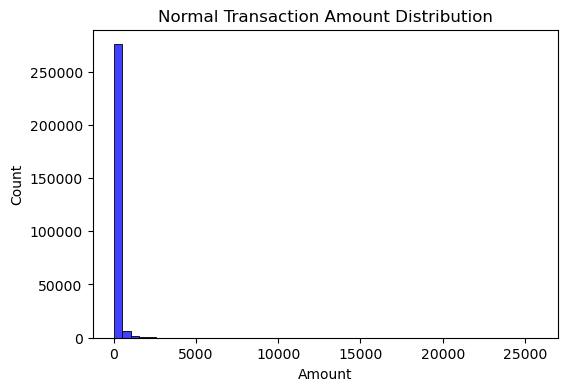

In [13]:
plt.figure(figsize = (6,4))
sns.histplot(normal_df['Amount'],bins = 50,color = 'blue')
plt.title("Normal Transaction Amount Distribution")
plt.show()

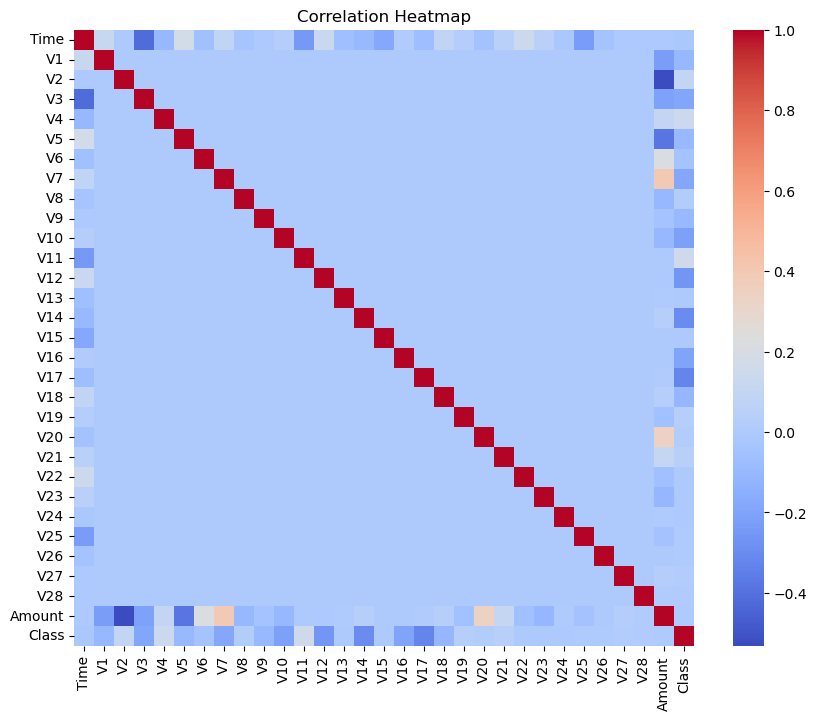

In [14]:
plt.figure(figsize =(10,8))
sns.heatmap(df.corr(), cmap = "coolwarm")
plt.title("Correlation Heatmap")
plt.show()

FEATURE AND TARGET SELECTION

In [15]:
x = df.drop("Class",axis = 1)
y = df["Class"]

print("Feature shape :",x.shape)
print("Target shape :",y.shape)

Feature shape : (284807, 30)
Target shape : (284807,)


TRAIN - TEST - SPLIT

In [16]:
x_train,x_test, y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)
print("Training data shape :",x_train.shape)
print("Testing data shape :",x_test.shape)

Training data shape : (227845, 30)
Testing data shape : (56962, 30)


APPLY SMOTE

In [17]:
smote = SMOTE(random_state = 42)
x_train_sm,y_train_sm = smote.fit_resample(x_train,y_train)

print("Before SMOTE :",y_train.value_counts())
print("After SMOTE :",y_train.value_counts())

Before SMOTE : Class
0    227451
1       394
Name: count, dtype: int64
After SMOTE : Class
0    227451
1       394
Name: count, dtype: int64


FEATURE SCALING

In [18]:
scaler = StandardScaler()
x_train_sm = scaler.fit_transform(x_train_sm)
x_test = scaler.transform(x_test)

                                                 MODEL TRAINING SECTION (APPLY ALGORITHM)

1.LOGISTIC REGRESSION

a. Train Model

In [19]:
lr = LogisticRegression()
lr.fit(x_train_sm,y_train_sm)

y_pred_lr = lr.predict(x_test)

b. Evalution

In [20]:
print("Logistic Regression Performance")
print("Accuracy :",accuracy_score(y_test,y_pred_lr))
print("Precision :",precision_score(y_test,y_pred_lr))
print("Recall :",recall_score(y_test,y_pred_lr))
print("F1  score :",f1_score(y_test,y_pred_lr))

Logistic Regression Performance
Accuracy : 0.9917137740950107
Precision : 0.1624548736462094
Recall : 0.9183673469387755
F1  score : 0.27607361963190186


c. Confusion matrix

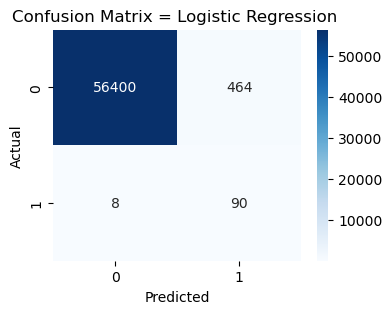

In [21]:
cm_lr = confusion_matrix(y_test,y_pred_lr)
plt.figure(figsize = (4,3))
sns.heatmap(cm_lr,annot = True ,fmt = 'd',cmap = 'Blues')
plt.title("Confusion Matrix = Logistic Regression ")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

d. ROC curve

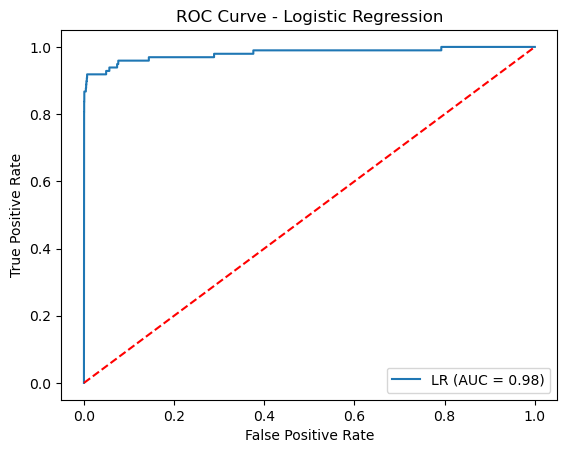

In [76]:
from sklearn.metrics import roc_curve, auc

y_prob_lr = lr.predict_proba(x_test)[:,1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

plt.figure()
plt.plot(fpr_lr, tpr_lr, label="LR (AUC = %0.2f)" % roc_auc_lr)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

2. DECISION TREE

a. Train Model

In [23]:
dt = DecisionTreeClassifier()
dt.fit(x_train_sm,y_train_sm)

y_pred_dt = dt.predict(x_test)

b. Evaluation

In [24]:
print("Decision Tree Performance")
print("Accuracy :",accuracy_score(y_test,y_pred_dt))
print("Precision :",precision_score(y_test,y_pred_dt))
print("Recall :",recall_score(y_test,y_pred_dt))
print("F1  score :",f1_score(y_test,y_pred_dt))

Decision Tree Performance
Accuracy : 0.9980162213405428
Precision : 0.4539877300613497
Recall : 0.7551020408163265
F1  score : 0.5670498084291188


c. Confusion Matrix

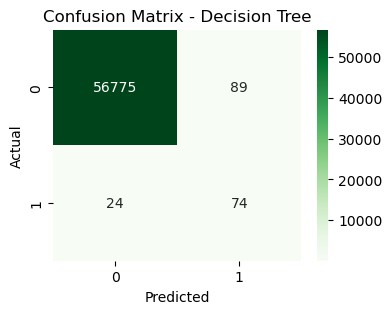

In [25]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(4,3))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

d. ROC Curve

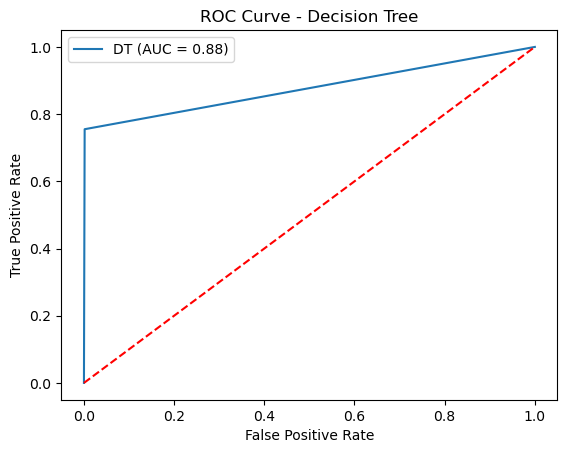

In [26]:
y_prob_dt = dt.predict_proba(x_test)[:,1]

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

plt.figure()
plt.plot(fpr_dt, tpr_dt, label="DT (AUC = %0.2f)" % roc_auc_dt)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()

3. KNN

a.Train

In [27]:
knn = KNeighborsClassifier()
knn.fit(x_train_sm,y_train_sm)

y_pred_knn = knn.predict(x_test)

b. Evaluation

In [29]:
print("KNN performance")
print("Accuracy:",accuracy_score(y_test,y_pred_knn))
print("Precision :",precision_score(y_test,y_pred_knn))
print("Recall :",recall_score(y_test,y_pred_knn))
print("F1 score :",f1_score(y_test,y_pred_knn))

KNN performance
Accuracy: 0.9984375548611355
Precision : 0.5290322580645161
Recall : 0.8367346938775511
F1 score : 0.6482213438735178


c. Confusion Matrix

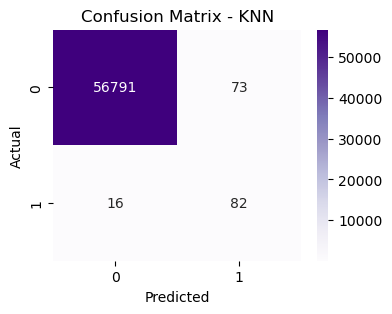

In [30]:
cm_knn = confusion_matrix(y_test,y_pred_knn)
plt.figure(figsize = (4,3))
sns.heatmap(cm_knn,annot = True,fmt = 'd',cmap = "Purples")
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

d. ROC Curve

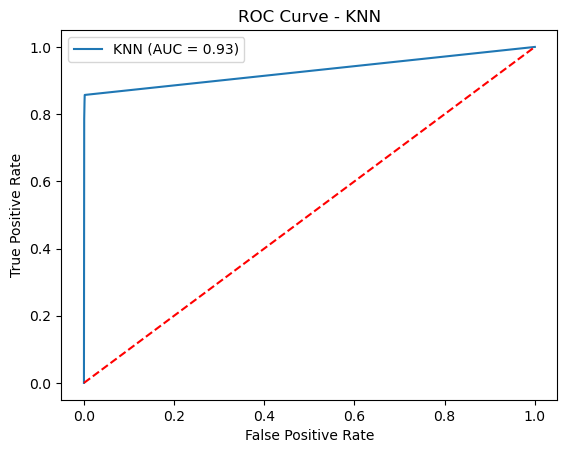

In [31]:
y_prob_knn = knn.predict_proba(x_test)[:,1]
fpr_knn,tpr_knn, _ = roc_curve(y_test,y_prob_knn)
roc_auc_knn = auc(fpr_knn,tpr_knn)

plt.figure()
plt.plot(fpr_knn,tpr_knn, label = "KNN (AUC = %0.2f)" % roc_auc_knn)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN")
plt.legend()
plt.show()


4. RANDOM FOREST

a. Train

In [28]:
rf = RandomForestClassifier()
rf.fit(x_train_sm,y_train_sm)

y_pred_rf = rf.predict(x_test)

b. Evaluation

In [32]:
print("Random Forest Classifier:")
print("Accuracy:",accuracy_score(y_test,y_pred_rf))
print("Precision :",precision_score(y_test,y_pred_rf))
print("Recall:",recall_score(y_test,y_pred_rf))
print("F1 score :",f1_score(y_test,y_pred_rf))

Random Forest Classifier:
Accuracy: 0.9995259997893332
Precision : 0.865979381443299
Recall: 0.8571428571428571
F1 score : 0.8615384615384616


c. Confusion Matrix

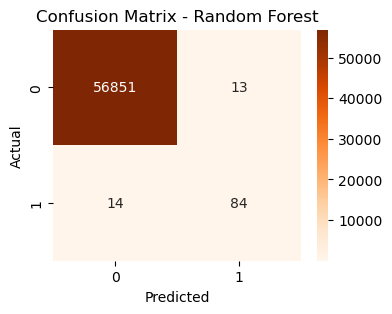

In [33]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(4,3))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

d. ROC CURVE

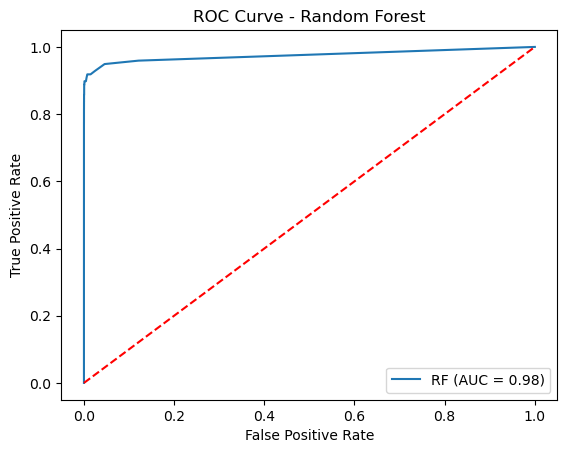

In [34]:
y_prob_rf = rf.predict_proba(x_test)[:,1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure()
plt.plot(fpr_rf, tpr_rf, label="RF (AUC = %0.2f)" % roc_auc_rf)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

MODEL COMPARISON TABLE

In [35]:
results = pd.DataFrame({
    "Model" :["Logistic Regression", "Decision Tree", "Random Forest", "KNN"],
                       "Accuracy":[
          accuracy_score(y_test,y_pred_lr),
          accuracy_score(y_test,y_pred_dt),
          accuracy_score(y_test,y_pred_rf),
          accuracy_score(y_test,y_pred_knn)
],
"precision":[
          accuracy_score(y_test,y_pred_lr),
          accuracy_score(y_test,y_pred_dt),
          accuracy_score(y_test,y_pred_rf),
          accuracy_score(y_test,y_pred_knn)
],
"Recall":[
          accuracy_score(y_test,y_pred_lr),
          accuracy_score(y_test,y_pred_dt),
          accuracy_score(y_test,y_pred_rf),
          accuracy_score(y_test,y_pred_knn)
],
"F1 score":[
          accuracy_score(y_test,y_pred_lr),
          accuracy_score(y_test,y_pred_dt),
          accuracy_score(y_test,y_pred_rf),
          accuracy_score(y_test,y_pred_knn)
]
})
results
    

,Model,Accuracy,precision,Recall,F1 score
0,Logistic Regression,0.991714,0.991714,0.991714,0.991714
1,Decision Tree,0.998016,0.998016,0.998016,0.998016
2,Random Forest,0.999526,0.999526,0.999526,0.999526
3,KNN,0.998438,0.998438,0.998438,0.998438


BEST MODEL SELECTION

In [36]:
best_model = results.loc[results["Recall"].idxmax()]
best_model

Model        Random Forest
Accuracy          0.999526
precision         0.999526
Recall            0.999526
F1 score          0.999526
Name: 2, dtype: object

COMPARISON GRAPH

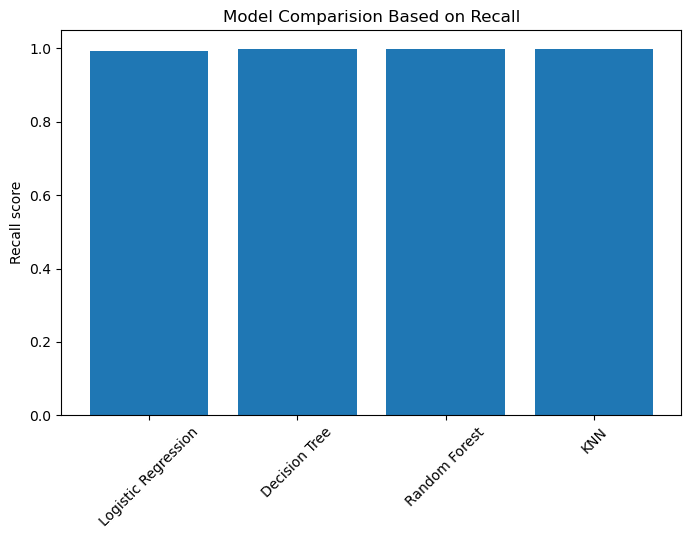

In [37]:
plt.figure(figsize = (8,5))
plt.bar(results["Model"],results["Recall"])
plt.xticks(rotation = 45)
plt.title("Model Comparision Based on Recall")
plt.ylabel("Recall score")
plt.show()

In [38]:
import joblib
joblib.dump(rf, "fraud_detection_model.pkl")

['fraud_detection_model.pkl']

In [39]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [40]:
loaded_model = joblib.load("fraud_detection_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")

sample = x_test[:1]
sample_scaled = loaded_scaler.transform(sample)

prediction = loaded_model.predict(sample_scaled)
print("Prediction:", prediction)

Prediction: [1]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [41]:
print("actual value:",y_test[:1].values)

actual value: [1]


IMPORT GridSearch

In [42]:
from sklearn.model_selection import GridSearchCV

Define Parameter

In [43]:
param_grid = {
    'n_estimators':[100],
    'max_depth':[None,10],
    'min_samples_split':[2]
}

Apply GridSearchCV

In [44]:
grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv = 2,
    scoring ='recall',
    n_jobs = -1
)
grid.fit(x_train_sm,y_train_sm)

GridSearchCV(cv=2, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [None, 10], 'min_samples_split': [2],
                         'n_estimators': [100]},
             scoring='recall')

Best Parameters

In [45]:
print("BEST PERFORMANCE :",grid.best_params_)
print("BEST RECALL SCORE :",grid.best_score_)

BEST PERFORMANCE : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
BEST RECALL SCORE : 0.9999252588784171


Evaluate Best Model

In [46]:
best_rf = grid.best_estimator_
y_pred_best = best_rf.predict(x_test)

print("Tuned Random Forest Performane")
print("Accuracy :",accuracy_score(y_test,y_pred_best))
print("Precision :",precision_score(y_test,y_pred_best))
print("Recall :",recall_score(y_test,y_pred_best))
print("F1 score :",f1_score(y_test,y_pred_best))

Tuned Random Forest Performane
Accuracy : 0.9995084442259752
Precision : 0.8645833333333334
Recall : 0.8469387755102041
F1 score : 0.8556701030927835


Confusion Matrics (Tuned Model)

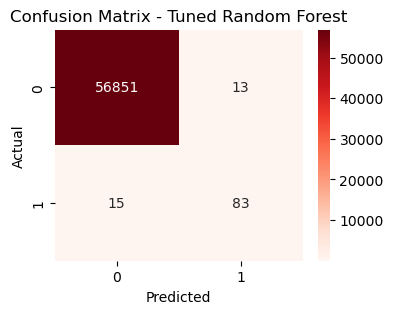

In [47]:
cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(4,3))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix - Tuned Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Logistic Regression metrics

In [49]:
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

Decision Tree Matrics

In [50]:
acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

Random Forest Matrics

In [51]:
acc_rf = accuracy_score(y_test, y_pred_best)
prec_rf = precision_score(y_test, y_pred_best)
rec_rf = recall_score(y_test, y_pred_best)
f1_rf = f1_score(y_test, y_pred_best)

KNN Matrics

In [52]:
acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn)
rec_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

COMPARISON TABLE 

In [55]:
comparison = pd.DataFrame({
    'Model':['Logistic Regression',
             'Decision Tree',
             'KNN',
             'Random Forest (Tuned)'],
    'Accuracy' :[acc_lr,acc_dt,acc_rf,acc_knn],
    'precision':[prec_lr,prec_dt,prec_rf,prec_knn],
    'Recall' :[rec_lr,rec_dt,rec_rf,prec_knn],
    'F1 score':[f1_lr,f1_dt,f1_rf,prec_knn]
})
comparison
    

,Model,Accuracy,precision,Recall,F1 score
0,Logistic Regression,0.991714,0.162455,0.918367,0.276074
1,Decision Tree,0.998016,0.453988,0.755102,0.567050
2,KNN,0.999508,0.864583,0.846939,0.855670
3,Random Forest (Tuned),0.998438,0.529032,0.529032,0.529032


In [56]:
comparison.style.background_gradient(cmap = "Greens")

,Model,Accuracy,precision,Recall,F1 score
0,Logistic Regression,0.991714,0.162455,0.918367,0.276074
1,Decision Tree,0.998016,0.453988,0.755102,0.567050
2,KNN,0.999508,0.864583,0.846939,0.855670
3,Random Forest (Tuned),0.998438,0.529032,0.529032,0.529032


FINAL MODEL SELECTION 

Based on evaluation metrics, KNN achieved the best F1-score and balanced performance.
Hence, KNN was selected as the final model.

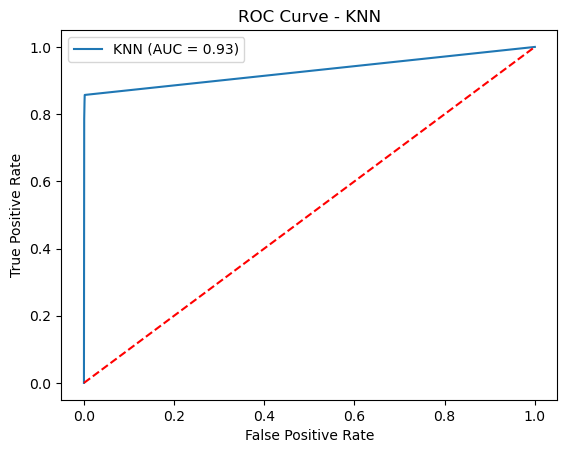

In [58]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob_knn = knn.predict_proba(x_test)[:,1]

fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
roc_auc_knn = auc(fpr_knn, tpr_knn)

plt.figure()
plt.plot(fpr_knn, tpr_knn, label="KNN (AUC = %0.2f)" % roc_auc_knn)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN")
plt.legend()
plt.show()

FEATURE IMPORTANCE 

Since KNN is a distance-based algorithm, it does not provide direct feature importance values.
All features contribute equally in distance calculation after scaling.

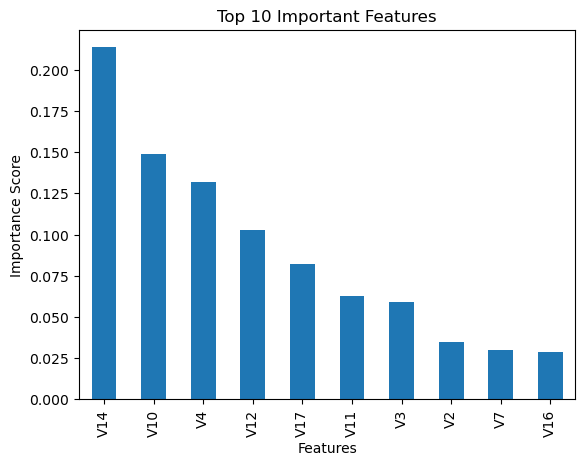

In [60]:

importances = best_rf.feature_importances_

# Feature names
features = x.columns

# Create Series
feat_imp = pd.Series(importances, index=features)

# Sort and take top 10
top_features = feat_imp.sort_values(ascending=False).head(10)

# Plot
plt.figure()
top_features.plot(kind='bar')
plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.show()

MODEL SAVING

In [61]:
final_model = knn

In [63]:
import joblib
joblib.dump(final_model,"fraud_detection_model.pkl")

['fraud_detection_model.pkl']

MODEL VERIFICATION

Fraud prediction

In [66]:
loaded_model = joblib.load("fraud_detection_model.pkl")

sample_predict = loaded_model.predict(x_test[0].reshape(1,-1))

print("Prediction:",sample_predict)

Prediction: [1]


Genuine prediction

In [69]:
genuine_index = np.where(y_test == 0)[0][0]
print("Index of genuine transcation:",genuine_index)

Index of genuine transcation: 1


In [70]:
sample_predict = loaded_model.predict(x_test[genuine_index].reshape(1,-1))

print("Prediction:",sample_predict)

Prediction: [0]


In [72]:
print("Actual :",y_test.iloc[genuine_index])
print("Predicted :",sample_predict)

Actual : 0
Predicted : [0]


Conclusion

The machine learning models were trained and evaluated for fraud detection.
Among all models, KNN performed best and was selected as the final model.
The model was saved and verified successfully.